### Configuração do Ambiente

In [1]:
import os
import torch, random, numpy as np
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU detectada: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('Nenhuma GPU detectada!')

GPU detectada: NVIDIA GeForce RTX 4070 Laptop GPU


### Obtenção e preparação do corpus

In [2]:
base_path = 'Fake.br-Corpus/full_texts'
fake_dir = os.path.join(base_path, 'fake')
true_dir = os.path.join(base_path, 'true')

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

def load_corpus(fake_dir, true_dir, max_samples=None):
    # Rótulo (label) das noticias verdadeiras é 1 e 0 são as falsas
    texts, labels = [], []
    for label, d in [(0, fake_dir), (1, true_dir)]:
        files = os.listdir(d)
        if max_samples:
            files = files[:max_samples]
        for f in files:
            with open(os.path.join(d, f), encoding='utf-8', errors='ignore') as fh:
                text = fh.read().strip()
                if len(text) > 0:
                    texts.append(text)
                    labels.append(label)
    # Retorna o dataset construído
    return pd.DataFrame({'text': texts, 'label': labels})

# Criação do corpus
df = load_corpus(fake_dir, true_dir) # TODO: remover limitação
print('Exemplos do conjunto de treinamento:')
print(df.sample(3))

# Divisão do corpus em train, val e test (80/10/10)
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])
print('Tamanho de cada subconjunto após divisão:')
print(f'train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')

Exemplos do conjunto de treinamento:
                                                   text  label
3098  Chorando as pitangas: Bonner posta frase de "d...      0
2531  Na Bahia,  adolescente de 14 anos prevê a próp...      0
4071  Segunda-feira, 12 de março. Bom dia! Aqui estã...      1
Tamanho de cada subconjunto após divisão:
train: 5760, val: 720, test: 720


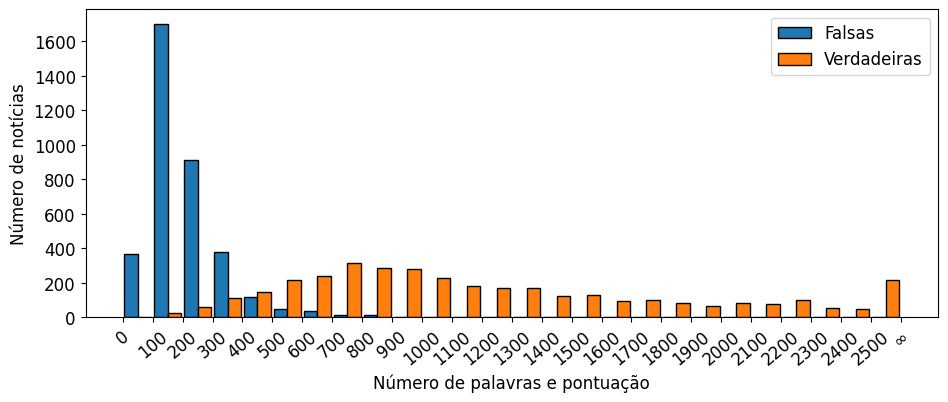

In [4]:
# Este código foi adaptado de https://github.com/Talendar/br_fake_news_detection
from matplotlib import pyplot as plt
import re

def count_words(texts: list):
    """
    Conta o número de palavras e pontuação em cada item da lista.
    Retorna uma lista com os tamanhos nas posições correspondentes.
    """
    counts = []
    for text in texts:
        num_words = len(re.findall(r"[\w']+|[.,!?;:/\"]", text))
        counts.append(num_words)
    return np.array(counts)


counts_fake = count_words(df[df['label'] == 0]['text'].values)
counts_true = count_words(df[df['label'] == 1]['text'].values)
intervals = list(range(0, 2601, 100))

# Representação de todos os itens com mais de 2500 em uma barra só
labels = intervals[:-1] + ['∞']
counts_fake = np.clip(counts_fake, 0, 2600)
counts_true = np.clip(counts_true, 0, 2600)

plt.figure(figsize=(11,4))
plt.rcParams.update({'font.size': 12})
plt.hist([counts_fake, counts_true], label=['Falsas', 'Verdadeiras'], rwidth=0.9, edgecolor='black', linewidth=1, bins=intervals)
# plt.hist(counts_true, label='Verdadeiras', alpha=0.4, rwidth=0.9, edgecolor='black', linewidth=1, bins=intervals)
plt.xticks(intervals, labels=labels, rotation=40)
# plt.title('Distribuição do comprimento das notícias por rótulo')
plt.xlabel('Número de palavras e pontuação', fontsize=12)
plt.ylabel('Número de notícias', fontsize=12)
plt.legend(loc='upper right')
plt.show()

### Tokenização do corpus e criação do dataset do HuggingFace

In [5]:
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')

# Converte DataFrames em Dataset do Hugging Face
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

# Realiza a tokenização
def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=256,  # Este limite deu resultados satisfatórios
        return_tensors='pt'
    )

# Aplica a tokenização
train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds   = val_ds.map(tokenize_batch, batched=True)
test_ds  = test_ds.map(tokenize_batch, batched=True)

# Define o formato do pytorch
cols = ['input_ids', 'attention_mask', 'token_type_ids', 'label']
train_ds.set_format(type='torch', columns=cols)
val_ds.set_format(type='torch', columns=cols)
test_ds.set_format(type='torch', columns=cols)

print(train_ds)
print('exemplo tokenizado:', {k: v.shape for k, v in train_ds[0].items()})


Map: 100%|██████████| 720/720 [00:00<00:00, 2700.50 examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5760
})
exemplo tokenizado: {'label': torch.Size([]), 'input_ids': torch.Size([256]), 'token_type_ids': torch.Size([256]), 'attention_mask': torch.Size([256])}


### Funções de treinamento e avaliação

In [6]:
# Definição de hiperparâmetros
batch_size = 8
epochs = 5
lr = 1e-5

In [7]:
# Preparação dos dados
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

In [8]:
# Função auxiliar do treinamento
def train_one_epoch(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)


# Função principal do treinamento
def train_model(model, train_loader, val_loader, batch_size, epochs, lr):
    optimizer = AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()  # Função de perda
    model.to(device)
    train_losses = []
    val_losses = []

    for epoch in tqdm(range(epochs), desc="Treinamento"):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        train_losses.append(train_loss)
        val_loss = evaluate(model, val_loader, criterion)
        val_losses.append(val_loss)
        print(f'Época {epoch+1:>2} — train loss: {train_loss:.4f} — val loss: {val_loss:.4f}')

    return train_losses, val_losses

In [9]:
# Função de validação
def evaluate(model, val_loader, criterion, print_metrics=False):
    total_loss = 0

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels = batch['label'].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )

            loss = criterion(outputs, labels)
            total_loss += loss.item()
            if print_metrics:
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    # Medidas de desempenho do modelo
    if print_metrics:
        acc  = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds)
        rec  = recall_score(all_labels, all_preds)
        f1   = f1_score(all_labels, all_preds)
        cmat = confusion_matrix(all_labels, all_preds)
        print(f'Loss     : {avg_loss:.4f}')
        print(f'Accuracy : {acc:.4f}')
        print(f'Precision: {prec:.4f}')
        print(f'Recall   : {rec:.4f}')
        print(f'F1-score : {f1:.4f}')
        print('Matriz de confusão:')
        for line in cmat:
            print(*(f'{x:4}' for x in line))

    return avg_loss

### Modelo baseline

In [10]:
class CustomBertimbauClassifier(nn.Module):
    """
    Modelo de classificação binária para detecção de fake news
    baseado no BERTimbau.
    Nesta versão inicial, apenas extrai o [CLS] e passa
    por uma camada linear (baseline).
    """

    def __init__(self, pretrained_model_name: str = 'neuralmind/bert-base-portuguese-cased', num_labels: int = 2):
        """
        Inicializa o modelo.
        Args:
        pretrained_model_name: nome do modelo BERTimbau pré-treinado.
        num_labels: número de classes de saída (2 para fake/true).
        """
        super().__init__()
        self.bert = AutoModel.from_pretrained(pretrained_model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_labels)


    def mean_pooling(self, token_embeddings: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Só para atender à interface.
        """
        raise NotImplementedError('Esta versão não possui o pooling alternativo.')


    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor, token_type_ids: torch.Tensor = None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # vetor [CLS]
        logits = self.classifier(cls_emb)
        # logits = torch.tanh(logits)
        return logits


### Instanciação

In [11]:
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
base_model = CustomBertimbauClassifier()

# Texto de exemplo
inputs = tokenizer('Urgente: exemplo dado', return_tensors='pt', padding=True)
with torch.no_grad():
    logits = base_model(**inputs)
print(logits)
print('Saída do modelo:', logits.shape)
assert logits.shape[-1] == 2, 'saída incorreta'
print('Modelo baseline funciona.')

tensor([[-0.0515, -0.1983]])
Saída do modelo: torch.Size([1, 2])
Modelo baseline funciona.


### Treinamento e avaliação do modelo baseline

In [ ]:
train_losses, val_losses = train_model(
    base_model, train_loader, val_loader,
    batch_size, epochs, lr
)

# Curvas de perda
x = [x for x in range(1, epochs+1)]
plt.figure(figsize=(8, 4))
plt.plot(x, train_losses, marker='o', label='Treino')
plt.plot(x, val_losses, marker='o', label='Validação')
# plt.title("Curvas de Perda")
plt.xticks(x)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Treinamento:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
print('Avaliação do modelo baseline no conjunto de teste:')
test_loss = evaluate(base_model, test_loader, nn.CrossEntropyLoss(), print_metrics=True)
print(f'Test loss: {test_loss:.4f}')

### Modelo com pooling alternativo

In [ ]:
class CustomBertimbauClassifier(nn.Module):
    """
    Modelo de classificação binária para detecção de fake news
    baseado no BERTimbau, com pooling alternativo.
    Estratágia de pooling:
    - Extrai o embedding do token [CLS].
    - Calcula a média dos embeddings dos tokens válidos.
    - Concatena [CLS] + média e aplica uma camada de classificação.
    """

    def __init__(self, pretrained_model_name: str = 'neuralmind/bert-base-portuguese-cased', num_labels: int = 2):
        """
        Inicializa o modelo.
        Args:
        pretrained_model_name: nome do modelo BERTimbau pré-treinado.
        num_labels: número de classes de saída (2 para fake/true).
        """
        super().__init__()
        self.bert = AutoModel.from_pretrained(pretrained_model_name)
        hidden_size = self.bert.config.hidden_size
        # Dobro devido à concatenação de [CLS] e média
        self.classifier = nn.Linear(2 * hidden_size, num_labels)


    def mean_pooling(self, token_embeddings: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Calcula a média dos embeddings válidos (ignora tokens de padding).
        Args:
        token_embeddings: tensor [batch_size, seq_len, hidden_size]
        attention_mask: tensor [batch_size, seq_len]
        Returns:
        Tensor [batch_size, hidden_size] com a média dos tokens válidos.
        """
        # Necessário para operação matemática
        mask = attention_mask.unsqueeze(-1).float()
        sum_tokens = (token_embeddings * mask).sum(dim=1)  # (B, H)
        # Clamp evita divisão por zero
        len_tokens = mask.sum(dim=1).clamp(min=1e-6)  # (B, 1)
        return sum_tokens / len_tokens  # (B, H)


    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor, token_type_ids: torch.Tensor = None) -> torch.Tensor:
        """
        Passagem direta no modelo.
        Passos:
        1. Obtém os embeddings da última camada do BERT.
        2. Extrai o vetor [CLS].
        3. Calcula a média dos embeddings válidos.
        4. Concatena [CLS] + média.
        5. Passa pelo classificador linear.
        Returns:
        logits: tensor [batch_size, num_labels]
        """
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # Vetor [CLS] "cru"
        mean_emb = self.mean_pooling(outputs.last_hidden_state, attention_mask)
        cls_mean = torch.cat([cls_emb, mean_emb], dim=1)
        logits = self.classifier(cls_mean)

        return logits

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
pool_model = CustomBertimbauClassifier()

# Texto de exemplo
inputs = tokenizer('Urgente: exemplo dado', return_tensors='pt', padding=True)
with torch.no_grad():
    logits = pool_model(**inputs)

print('Saída do modelo:', logits.shape)
assert logits.shape[-1] == 2, 'saída incorreta'
print('Modelo com pooling alternativo funciona.')

In [ ]:
train_losses, val_losses = train_model(
    pool_model, train_loader, val_loader,
    batch_size, epochs, lr
)

# Curvas de perda
x = [x for x in range(1, epochs+1)]
plt.figure(figsize=(8, 4))
plt.plot(x, train_losses, marker='o', label='Treino')
plt.plot(x, val_losses, marker='o', label='Validação')
# plt.title("Curvas de Perda")
plt.xticks(x)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print('Avaliação do modelo com pooling no conjunto de teste:')
test_loss = evaluate(pool_model, test_loader, nn.CrossEntropyLoss(), print_metrics=True)